In [905]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
from prophet import Prophet
from xgboost import XGBRegressor
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error,mean_absolute_error


In [906]:
data_path="data\\ai data new.csv"


In [907]:
df=pd.read_csv(data_path)
df
df['WEEK_START']=pd.to_datetime(df['WEEK_START'])
df

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT
0,2022-12-27,13,2022,12,52,948753.84,59307,NaN,NaN,NaN,NaN,8591742.37
1,2023-01-03,13,2023,1,1,8591742.37,509008,948753.84,59307.0,NaN,NaN,9293707.53
2,2023-01-10,13,2023,1,2,9293707.53,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80
3,2023-01-17,13,2023,1,3,9308526.80,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15
4,2023-01-24,13,2023,1,4,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86
...,...,...,...,...,...,...,...,...,...,...,...,...
515,2025-05-20,16,2025,5,21,16163852.23,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56
516,2025-05-27,16,2025,5,22,17529576.56,117082,16163852.23,115439.0,15570153.12,103855.0,17400796.00
517,2025-06-03,16,2025,6,23,17400796.00,113021,17529576.56,117082.0,16163852.23,115439.0,15587878.31
518,2025-06-10,16,2025,6,24,15587878.31,100822,17400796.00,113021.0,17529576.56,117082.0,2718883.95


In [908]:
holidays_path = 'data\\seasons.xlsx'
try:
    holidays_df = pd.read_excel(holidays_path)
except FileNotFoundError:
    print(f"Error: {holidays_path} not found")
    holidays_df = pd.DataFrame()
holidays_df['Date'] = pd.to_datetime(holidays_df['Date'])
holidays_df



,Date,Day,Season Name,Category,Year,Type,Notes
0,2019-01-01,Tuesday,New Year's Day,New Year,2019,Public,Fixed date
1,2019-01-07,Monday,Coptic Christmas,Coptic Christmas,2019,Christian,Christian employees only
2,2019-04-25,Thursday,Sinai Liberation Day,Sinai Liberatio,2019,Public,NaN
3,2019-04-28,Sunday,Sham El-Nessim,Sham El-Nessim,2019,Christian,Spring festival (Coptic Easter Mon)
4,2019-05-01,Wednesday,Labour Day,Labour Day,2019,Public,NaN
...,...,...,...,...,...,...,...
124,2025-06-07,Saturday,Eid al-Adha (Start),Eid al-Adha,2025,Islamic,5-day holiday (Sat-Wed)
125,2025-06-26,Thursday,Islamic New Year,Islamic New Year,2025,Islamic,NaN
126,2025-06-30,Monday,June 30 Revolution Day,30 June revolution,2025,Public,NaN
127,2025-09-05,Friday,Prophet Muhammad’s Birthday,Prophet Muhammad’s Birthday,2025,Islamic,Long weekend (Fri-Sun)


In [909]:
def get_holiday_features_for_week(week_start, holidays_df):
    """
    Calculates holiday features for a given week.
    
    Args:
        week_start (datetime): The starting date of the week (e.g., Monday).
        holidays_df (DataFrame): The dataframe of all holidays.
        
    Returns:
        dict: A dictionary containing holiday features for that week.
    """
    week_end = week_start + timedelta(days=6)
    
    holidays_in_week = holidays_df[
        (holidays_df['Date'] >= week_start) & (holidays_df['Date'] <= week_end)
    ]

    num_holiday_days = len(holidays_in_week)

    holiday_name = holidays_in_week['Season Name'].unique().tolist()
    holiday_types = holidays_in_week['Type'].unique().tolist()
    
    return {
        'num_holiday_days': num_holiday_days,
        'holiday_names': holiday_name,
        'holiday_types': holiday_types
    }

In [910]:
holiday_features = df['WEEK_START'].apply(
    lambda date: get_holiday_features_for_week(date, holidays_df)
)

holiday_features_df = pd.json_normalize(holiday_features)
holiday_features_df.head()

df = pd.concat([df, holiday_features_df], axis=1)

for h_type in holidays_df['Type'].unique():
    df[f'type_{h_type.lower()}'] = df['holiday_types'].apply(lambda x: 1 if h_type in x else 0)


major_holidays = ['Eid al-Fitr', 'Eid al-Adha', 'New Year', '6-Oct', 'Labour Day']
for h_name in major_holidays:
    df[f'name_{h_name.lower().replace(" ", "_")}'] = df['holiday_names'].apply(lambda x: 1 if h_name in x else 0)

df = df.drop(columns=['holiday_types', 'holiday_names'])

df[df['num_holiday_days'] > 0].head()

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,num_holiday_days,type_public,type_christian,type_islamic,type_school,type_virus,name_eid_al-fitr,name_eid_al-adha,name_new_year,name_6-oct,name_labour_day
0,2022-12-27,13,2022,12,52,948753.84,59307,NaN,NaN,NaN,NaN,8591742.37,1,1,0,0,0,0,0,0,0,0,0
1,2023-01-03,13,2023,1,1,8591742.37,509008,948753.84,59307.0,NaN,NaN,9293707.53,1,0,1,0,0,0,0,0,0,0,0
4,2023-01-24,13,2023,1,4,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86,1,0,0,0,1,0,0,0,0,0,0
6,2023-02-07,13,2023,2,6,8906610.53,528915,9678802.86,561256.0,9706838.15,560539.0,8812601.72,1,0,0,0,1,0,0,0,0,0,0
12,2023-03-21,13,2023,3,12,8281173.60,487820,7397760.62,441528.0,8843598.52,529256.0,8815387.25,1,0,0,1,0,0,0,0,0,0,0


In [911]:
print(df.columns)

Index(['WEEK_START', 'MAIN_BILLER_ID', 'YEAR', 'MONTH', 'WEEK_NUMBER',
       'TOTAL_AMOUNT', 'TRANSACTION_COUNT', 'LAST_WEEK_TOTAL_AMOUNT',
       'LAST_WEEK_TRANSACTION_COUNT', 'LAST_2WEEK_TOTAL_AMOUNT',
       'LAST_2WEEK_TRANSACTION_COUNT', 'NEXT_WEEK_TOTAL_AMOUNT',
       'num_holiday_days', 'type_public', 'type_christian ', 'type_islamic',
       'type_school', 'type_virus', 'name_eid_al-fitr', 'name_eid_al-adha',
       'name_new_year', 'name_6-oct', 'name_labour_day'],
      dtype='object')


In [912]:
# df['RATIO_TOTAL_LAST_WEEK'] = df['TOTAL_AMOUNT'] / df['LAST_WEEK_TOTAL_AMOUNT']
# df['RATIO_TOTAL_LAST_2WEEK'] = df['TOTAL_AMOUNT'] / df['LAST_2WEEK_TOTAL_AMOUNT']
# df['RATIO_TRANS_LAST_WEEK'] = df['TRANSACTION_COUNT'] / df['LAST_WEEK_TRANSACTION_COUNT']
# df['RATIO_TRANS_LAST_2WEEK'] = df['TRANSACTION_COUNT'] / df['LAST_2WEEK_TRANSACTION_COUNT']

In [913]:
df

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,num_holiday_days,type_public,type_christian,type_islamic,type_school,type_virus,name_eid_al-fitr,name_eid_al-adha,name_new_year,name_6-oct,name_labour_day
0,2022-12-27,13,2022,12,52,948753.84,59307,NaN,NaN,NaN,NaN,8591742.37,1,1,0,0,0,0,0,0,0,0,0
1,2023-01-03,13,2023,1,1,8591742.37,509008,948753.84,59307.0,NaN,NaN,9293707.53,1,0,1,0,0,0,0,0,0,0,0
2,2023-01-10,13,2023,1,2,9293707.53,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80,0,0,0,0,0,0,0,0,0,0,0
3,2023-01-17,13,2023,1,3,9308526.80,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15,0,0,0,0,0,0,0,0,0,0,0
4,2023-01-24,13,2023,1,4,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86,1,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,2025-05-20,16,2025,5,21,16163852.23,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56,0,0,0,0,0,0,0,0,0,0,0
516,2025-05-27,16,2025,5,22,17529576.56,117082,16163852.23,115439.0,15570153.12,103855.0,17400796.00,0,0,0,0,0,0,0,0,0,0,0
517,2025-06-03,16,2025,6,23,17400796.00,113021,17529576.56,117082.0,16163852.23,115439.0,15587878.31,3,0,0,1,1,0,0,0,0,0,0
518,2025-06-10,16,2025,6,24,15587878.31,100822,17400796.00,113021.0,17529576.56,117082.0,2718883.95,0,0,0,0,0,0,0,0,0,0,0


In [914]:
df = df.apply(lambda x: x.astype(int) if x.name not in ['date','WEEK_START'] and x.notnull().all() else x)


In [915]:
df.set_index('WEEK_START', inplace=True)

In [916]:
df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,num_holiday_days,type_public,type_christian,type_islamic,type_school,type_virus,name_eid_al-fitr,name_eid_al-adha,name_new_year,name_6-oct,name_labour_day
WEEK_START,,,,,,,,,,,,,,,,,,,,,,
2022-12-27,13,2022,12,52,948753,59307,NaN,NaN,NaN,NaN,8591742.37,1,1,0,0,0,0,0,0,0,0,0
2023-01-03,13,2023,1,1,8591742,509008,948753.84,59307.0,NaN,NaN,9293707.53,1,0,1,0,0,0,0,0,0,0,0
2023-01-10,13,2023,1,2,9293707,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80,0,0,0,0,0,0,0,0,0,0,0
2023-01-17,13,2023,1,3,9308526,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15,0,0,0,0,0,0,0,0,0,0,0
2023-01-24,13,2023,1,4,9706838,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86,1,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-20,16,2025,5,21,16163852,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56,0,0,0,0,0,0,0,0,0,0,0
2025-05-27,16,2025,5,22,17529576,117082,16163852.23,115439.0,15570153.12,103855.0,17400796.00,0,0,0,0,0,0,0,0,0,0,0
2025-06-03,16,2025,6,23,17400796,113021,17529576.56,117082.0,16163852.23,115439.0,15587878.31,3,0,0,1,1,0,0,0,0,0,0


In [917]:
split_date='2025-06-17'
df = df[df.index < split_date]

In [918]:
pd.set_option('display.max_columns', None)
df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,num_holiday_days,type_public,type_christian,type_islamic,type_school,type_virus,name_eid_al-fitr,name_eid_al-adha,name_new_year,name_6-oct,name_labour_day
WEEK_START,,,,,,,,,,,,,,,,,,,,,,
2022-12-27,13,2022,12,52,948753,59307,NaN,NaN,NaN,NaN,8591742.37,1,1,0,0,0,0,0,0,0,0,0
2023-01-03,13,2023,1,1,8591742,509008,948753.84,59307.0,NaN,NaN,9293707.53,1,0,1,0,0,0,0,0,0,0,0
2023-01-10,13,2023,1,2,9293707,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80,0,0,0,0,0,0,0,0,0,0,0
2023-01-17,13,2023,1,3,9308526,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15,0,0,0,0,0,0,0,0,0,0,0
2023-01-24,13,2023,1,4,9706838,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86,1,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-13,16,2025,5,20,15570153,103855,15702655.05,108529.0,19611872.05,127050.0,16163852.23,0,0,0,0,0,0,0,0,0,0,0
2025-05-20,16,2025,5,21,16163852,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56,0,0,0,0,0,0,0,0,0,0,0
2025-05-27,16,2025,5,22,17529576,117082,16163852.23,115439.0,15570153.12,103855.0,17400796.00,0,0,0,0,0,0,0,0,0,0,0


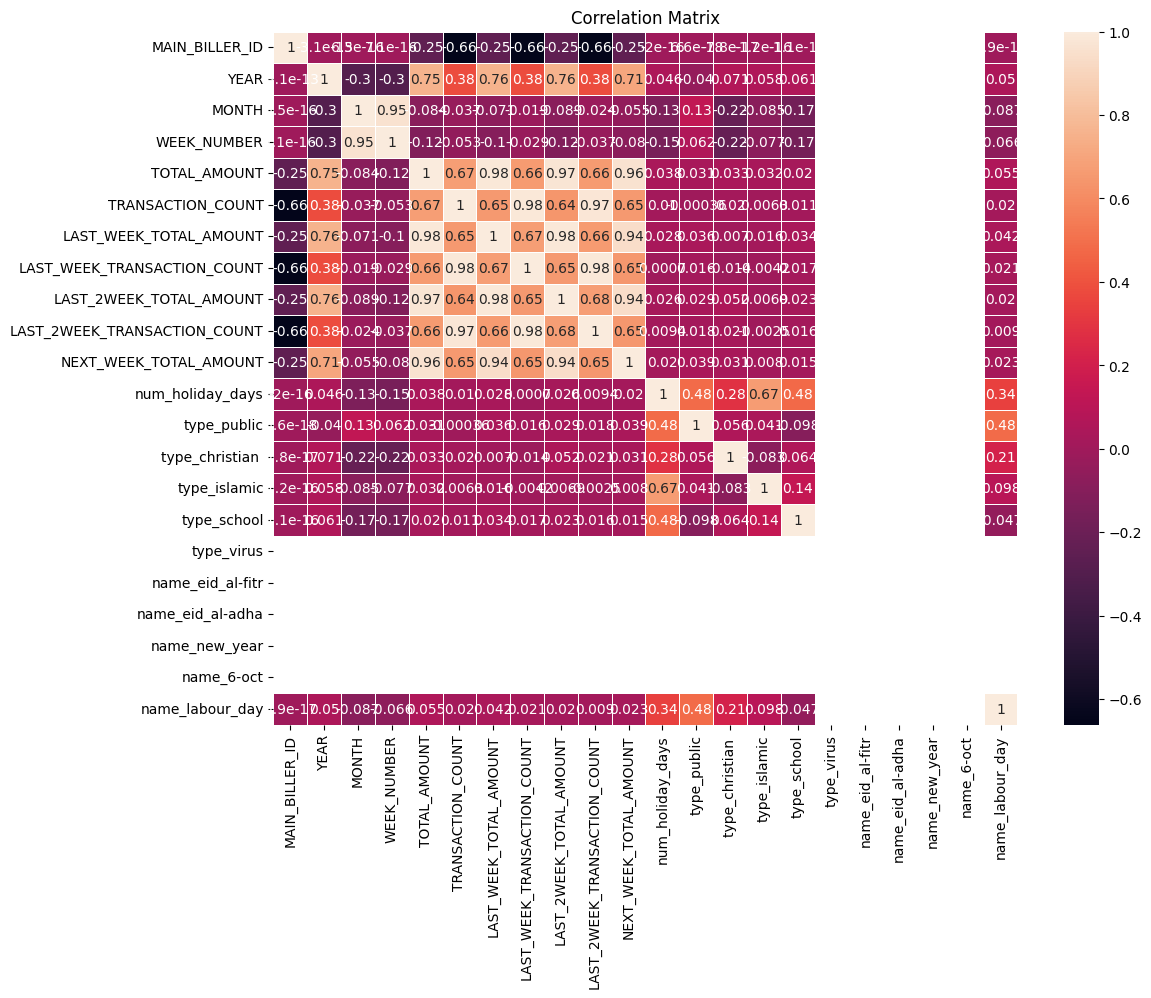

In [919]:
corr_matrix = df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, linewidths=0.5, ax=ax)
plt.title("Correlation Matrix")
plt.show()



In [920]:
# correlation_matrix = df.corr()
# corr_target = correlation_matrix['NEXT_WEEK_TOTAL_AMOUNT'].sort_values(ascending=False)
# cols_to_drop = corr_target[corr_target < 0.05].index.tolist()
# cols_to_keep = ['MAIN_BILLER_ID']
# df = df[cols_to_keep + [col for col in df.columns.tolist() if col not in cols_to_drop]]

# df

In [921]:
split_date='2025-05-06'
train_df = df[df.index < split_date]
test_df = df[df.index >= split_date]

In [922]:
train_df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,num_holiday_days,type_public,type_christian,type_islamic,type_school,type_virus,name_eid_al-fitr,name_eid_al-adha,name_new_year,name_6-oct,name_labour_day
WEEK_START,,,,,,,,,,,,,,,,,,,,,,
2022-12-27,13,2022,12,52,948753,59307,NaN,NaN,NaN,NaN,8591742.37,1,1,0,0,0,0,0,0,0,0,0
2023-01-03,13,2023,1,1,8591742,509008,948753.84,59307.0,NaN,NaN,9293707.53,1,0,1,0,0,0,0,0,0,0,0
2023-01-10,13,2023,1,2,9293707,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80,0,0,0,0,0,0,0,0,0,0,0
2023-01-17,13,2023,1,3,9308526,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15,0,0,0,0,0,0,0,0,0,0,0
2023-01-24,13,2023,1,4,9706838,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86,1,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-01,16,2025,4,14,17714663,121051,19608880.54,117056.0,14821924.36,99628.0,15630703.88,1,0,0,1,0,0,0,0,0,0,0
2025-04-08,16,2025,4,15,15630703,107803,17714663.86,121051.0,19608880.54,117056.0,15825971.44,0,0,0,0,0,0,0,0,0,0,0
2025-04-15,16,2025,4,16,15825971,113418,15630703.88,107803.0,17714663.86,121051.0,17876336.61,1,0,1,0,0,0,0,0,0,0,0


In [923]:
test_df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,num_holiday_days,type_public,type_christian,type_islamic,type_school,type_virus,name_eid_al-fitr,name_eid_al-adha,name_new_year,name_6-oct,name_labour_day
WEEK_START,,,,,,,,,,,,,,,,,,,,,,
2025-05-06,13,2025,5,19,24106173,742925,26168053.25,773146.0,2.390330e+07,741721.0,23903262.52,0,0,0,0,0,0,0,0,0,0,0
2025-05-13,13,2025,5,20,23903262,736450,24106173.86,742925.0,2.616805e+07,773146.0,24094654.79,0,0,0,0,0,0,0,0,0,0,0
2025-05-20,13,2025,5,21,24094654,737747,23903262.52,736450.0,2.410617e+07,742925.0,25321501.75,0,0,0,0,0,0,0,0,0,0,0
2025-05-27,13,2025,5,22,25321501,750389,24094654.79,737747.0,2.390326e+07,736450.0,25210754.96,0,0,0,0,0,0,0,0,0,0,0
2025-06-03,13,2025,6,23,25210754,767465,25321501.75,750389.0,2.409465e+07,737747.0,23428591.47,3,0,0,1,1,0,0,0,0,0,0
2025-06-10,13,2025,6,24,23428591,720012,25210754.96,767465.0,2.532150e+07,750389.0,4326669.57,0,0,0,0,0,0,0,0,0,0,0
2025-05-06,14,2025,5,19,11580632,424643,11948048.26,436537.0,1.138851e+07,421185.0,10907553.02,0,0,0,0,0,0,0,0,0,0,0
2025-05-13,14,2025,5,20,10907553,407647,11580632.17,424643.0,1.194805e+07,436537.0,11332411.62,0,0,0,0,0,0,0,0,0,0,0
2025-05-20,14,2025,5,21,11332411,414264,10907553.02,407647.0,1.158063e+07,424643.0,11995214.35,0,0,0,0,0,0,0,0,0,0,0


In [924]:
# features=["MAIN_BILLER_ID","YEAR","MONTH","WEEK_NUMBER","TOTAL_AMOUNT","TRANSACTION_COUNT","LAST_WEEK_TOTAL_AMOUNT","LAST_WEEK_TRANSACTION_COUNT",	"LAST_2WEEK_TOTAL_AMOUNT",	"LAST_2WEEK_TRANSACTION_COUNT","RATIO_TOTAL_LAST_WEEK","RATIO_TOTAL_LAST_2WEEK","RATIO_TRANS_LAST_WEEK","RATIO_TRANS_LAST_2WEEK"]
pred="NEXT_WEEK_TOTAL_AMOUNT"

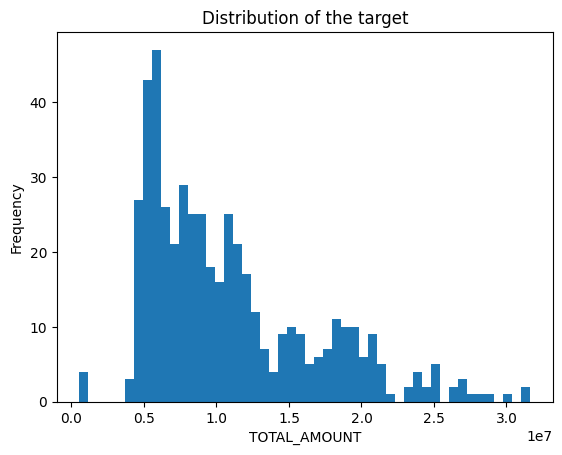

In [925]:

# distribution of the target
plt.hist(train_df['TOTAL_AMOUNT'], bins=50)
plt.title('Distribution of the target')
plt.xlabel('TOTAL_AMOUNT')
plt.ylabel('Frequency')
plt.show()


In [926]:
X_train = train_df.drop(pred, axis=1)   # features
y_train = train_df[pred]    # target

X_test = test_df.drop(pred, axis=1)
y_test = test_df[pred]    

In [927]:
features = list(X_test.columns)

In [928]:
X_train


,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,num_holiday_days,type_public,type_christian,type_islamic,type_school,type_virus,name_eid_al-fitr,name_eid_al-adha,name_new_year,name_6-oct,name_labour_day
WEEK_START,,,,,,,,,,,,,,,,,,,,,
2022-12-27,13,2022,12,52,948753,59307,NaN,NaN,NaN,NaN,1,1,0,0,0,0,0,0,0,0,0
2023-01-03,13,2023,1,1,8591742,509008,948753.84,59307.0,NaN,NaN,1,0,1,0,0,0,0,0,0,0,0
2023-01-10,13,2023,1,2,9293707,545412,8591742.37,509008.0,948753.84,59307.0,0,0,0,0,0,0,0,0,0,0,0
2023-01-17,13,2023,1,3,9308526,554002,9293707.53,545412.0,8591742.37,509008.0,0,0,0,0,0,0,0,0,0,0,0
2023-01-24,13,2023,1,4,9706838,560539,9308526.80,554002.0,9293707.53,545412.0,1,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-01,16,2025,4,14,17714663,121051,19608880.54,117056.0,14821924.36,99628.0,1,0,0,1,0,0,0,0,0,0,0
2025-04-08,16,2025,4,15,15630703,107803,17714663.86,121051.0,19608880.54,117056.0,0,0,0,0,0,0,0,0,0,0,0
2025-04-15,16,2025,4,16,15825971,113418,15630703.88,107803.0,17714663.86,121051.0,1,0,1,0,0,0,0,0,0,0,0


## model

In [929]:
model =XGBRegressor(
    objective='reg:absoluteerror',  # regression objective
    n_estimators=3000,              # number of trees
    learning_rate=0.1,             # step size shrinkage
    max_depth=8,                   # maximum tree depth
    subsample=0.8,                 # % of data used per tree
    colsample_bytree=0.8,          # % of features used per tree
    reg_alpha=0.7,                 # L1 regularization term
    reg_lambda=0.1,                  # L2 regularization term
    random_state=42                # for reproducibility
)

# Fit the model
model.fit(X_train, y_train)

,objective,'reg:absoluteerror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


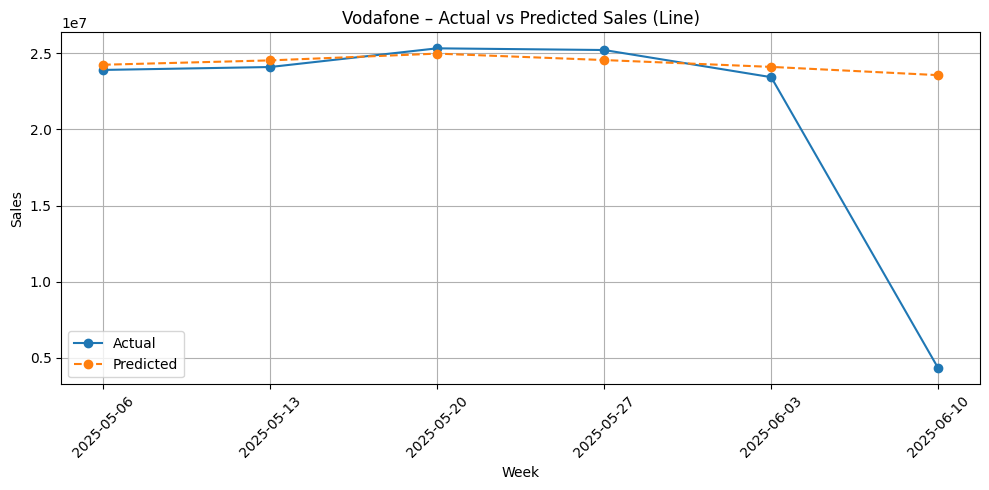

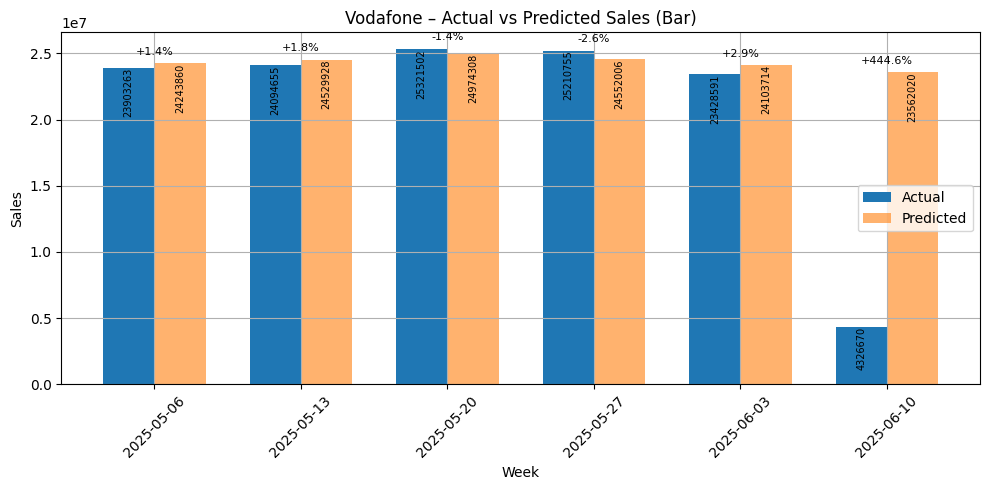

[Vodafone] MAE: 3615381.06 (n=6)


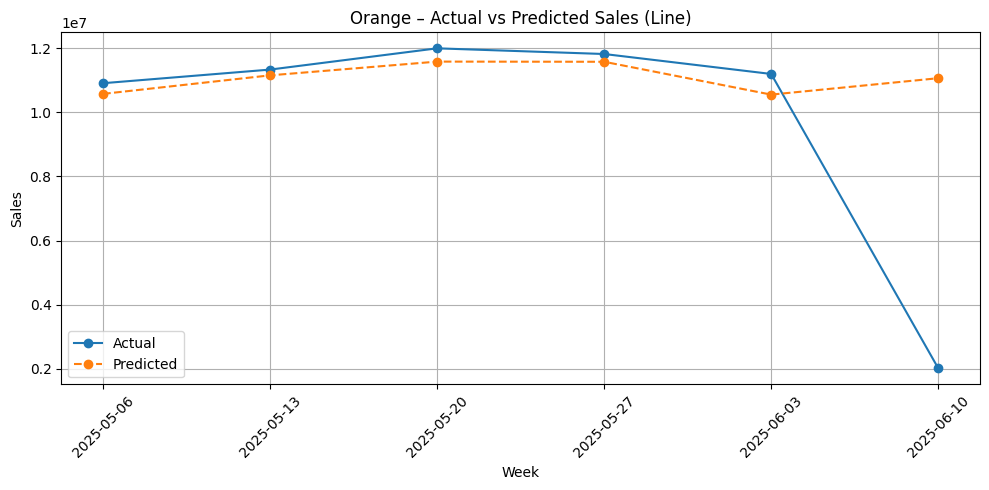

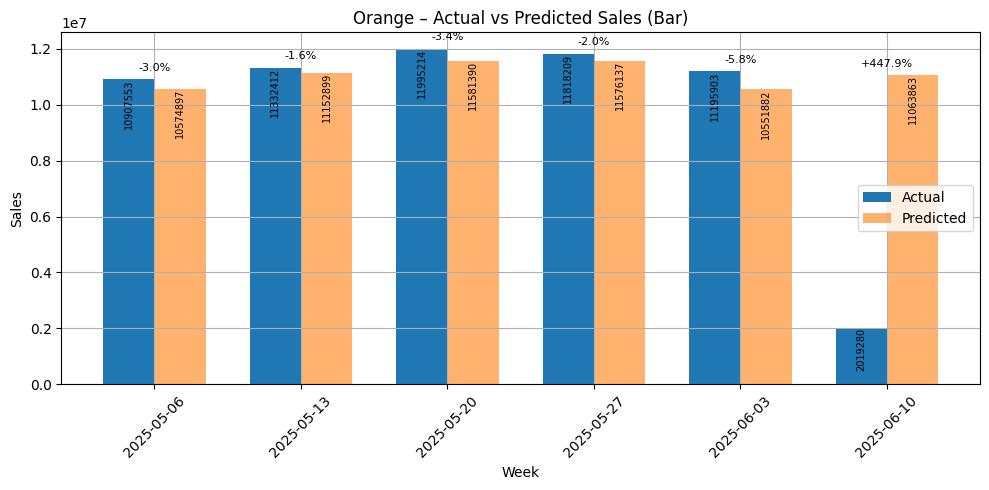

[Orange] MAE: 1809444.84 (n=6)


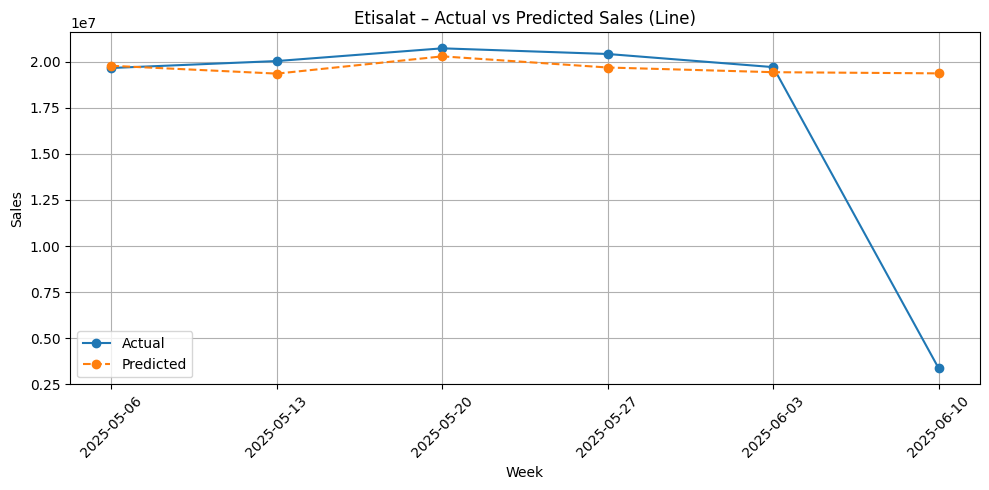

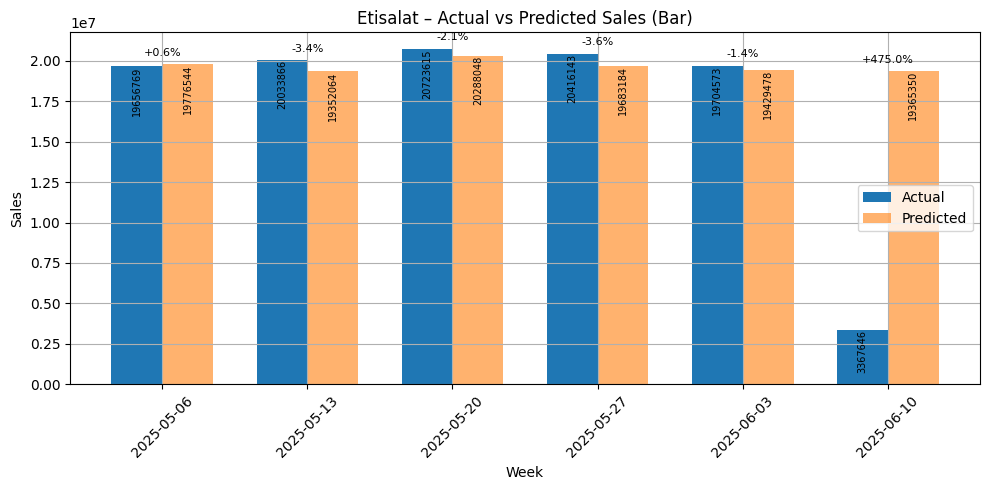

[Etisalat] MAE: 3040483.57 (n=6)


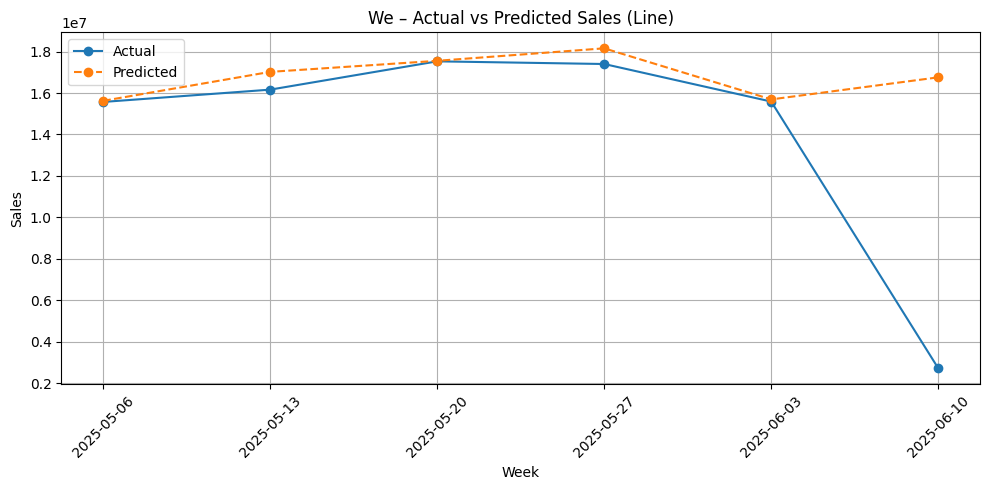

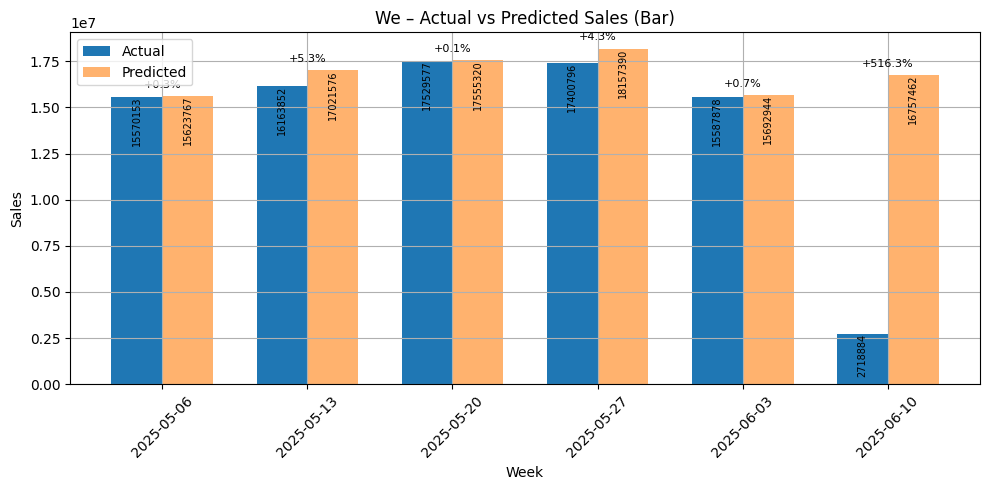

[We] MAE: 2639553.14 (n=6)


In [930]:
# ----------------------------------
# PREDICTION PLOTS and ROW COLLECTION
# ----------------------------------
from sklearn.metrics import mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

records = []   # <-- rows for the Excel file
product_name = {13: 'Vodafone', 14: 'Orange', 15: 'Etisalat', 16: 'We'}

for product, group in test_df.groupby('MAIN_BILLER_ID'):
    group = group.sort_index()

    X_test = group[features]
    y_true = group[pred].values.flatten()
    y_pred = model.predict(X_test).flatten()

    # ---------- collect one row per week ----------
    pct_diff = (y_pred - y_true) / y_true * 100     # +ve = over-predict
    records.extend(
        {
            "MAIN_BILLER_ID": product,
            "Product": product_name.get(product, product),
            "WEEK_START": group.index[i],
            "Actual":    y_true[i],
            "Predicted": y_pred[i],
            "Percentage": pct_diff[i],
        }
        for i in range(len(y_true))
    )

    # ---------- line (dot) plot ----------
    plt.figure(figsize=(10, 5))
    plt.plot(group.index, y_true, marker='o', label='Actual')
    plt.plot(group.index, y_pred, marker='o', linestyle='--', label='Predicted')
    plt.title(f"{product_name[product]} – Actual vs Predicted Sales (Line)")
    plt.xlabel("Week")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.gca().set_xticks(group.index)
    plt.gca().set_xticklabels(group.index.strftime('%Y-%m-%d'))
    plt.tight_layout()
    plt.show()

    # ---------- bar plot with annotations ----------
    plt.figure(figsize=(10, 5))
    width, x = 0.35, np.arange(len(y_true))
    plt.bar(x - width/2, y_true, width, label='Actual')
    plt.bar(x + width/2, y_pred, width, label='Predicted', alpha=0.6)

    for i in range(len(x)):
        plt.text(i - width/2, y_true[i] - 3,  f"{y_true[i]:.0f}",
                 ha='center', va='top', rotation=90, fontsize=7, color='black')
        plt.text(i + width/2, y_pred[i] - 3, f"{y_pred[i]:.0f}",
                 ha='center', va='top', rotation=90, fontsize=7, color='black')
        tallest = max(y_true[i], y_pred[i])
        plt.text(i, tallest * 1.02, f"{pct_diff[i]:+.1f}%",
                 ha='center', va='bottom', fontsize=8, color='black')

    plt.title(f"{product_name[product]} – Actual vs Predicted Sales (Bar)")
    plt.xlabel("Week")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.xticks(ticks=x, labels=group.index.strftime('%Y-%m-%d'), rotation=45)
    plt.tight_layout()
    plt.show()

    # optional: error metric
    mae = mean_absolute_error(y_true, y_pred)
    print(f"[{product_name[product]}] MAE: {mae:.2f} (n={len(y_true)})")

In [931]:
df.head()

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,num_holiday_days,type_public,type_christian,type_islamic,type_school,type_virus,name_eid_al-fitr,name_eid_al-adha,name_new_year,name_6-oct,name_labour_day
WEEK_START,,,,,,,,,,,,,,,,,,,,,,
2022-12-27,13,2022,12,52,948753,59307,NaN,NaN,NaN,NaN,8591742.37,1,1,0,0,0,0,0,0,0,0,0
2023-01-03,13,2023,1,1,8591742,509008,948753.84,59307.0,NaN,NaN,9293707.53,1,0,1,0,0,0,0,0,0,0,0
2023-01-10,13,2023,1,2,9293707,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80,0,0,0,0,0,0,0,0,0,0,0
2023-01-17,13,2023,1,3,9308526,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15,0,0,0,0,0,0,0,0,0,0,0
2023-01-24,13,2023,1,4,9706838,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86,1,0,0,0,1,0,0,0,0,0,0


In [932]:
# ----------------------------------
# SAVE collected rows to Excel
# ----------------------------------
import pandas as pd

df_out = pd.DataFrame(records)
df_out.to_excel("data\\predictions_vs_actual.xlsx", index=False)

print("Excel file written: predictions_vs_actual.xlsx "
      "(columns: MAIN_BILLER_ID, Product, WEEK_START, Actual, Predicted, Percentage)")

Excel file written: predictions_vs_actual.xlsx (columns: MAIN_BILLER_ID, Product, WEEK_START, Actual, Predicted, Percentage)


In [933]:
y_pred

array([1.5623767e+07, 1.7021576e+07, 1.7555320e+07, 1.8157390e+07,
       1.5692944e+07, 1.6757462e+07], dtype=float32)